# Resolución Trabajo Práctico 02

## Integrantes

- Gaspar Acevedo Zain

## Carga del dataset

### Imports y carga del dataset

In [783]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [784]:
df_procesado = pd.read_csv("../dataset/sneep-2023-procesamiento.csv")

In [785]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Helper functions

In [786]:
# Devuelve datos relativos a columnas numéricas, tales como media, skewness, kurtosis, entre otros
def get_metrics_from_numeric_column(data, column):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    moda = (data[column]).mode()[0]
    mediana = (data[column]).median()
    var = (data[column]).var()
    std = (data[column]).std()
    min = (data[column]).min()
    max = (data[column]).max()

    return media, moda, mediana, min, max, var, std, skewness, kurtosis

In [787]:
# Devuelve métricas relacionadas al rango Intercuartil
def get_iqr_metrics(data, column):
    Q1 = data[column].quantile(0.25)
    Q2 = data[column].quantile(0.50)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1
    min_iqr = Q1 - 1.5*IQR
    max_iqr = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_iqr, max_iqr

In [788]:
# defino un color default
default_green_color = "#1F968BFF"

# Código provisto por la materia
# Función para graficar Histogramas, junto con skewness, kurtosis, media, varianza, y/o desvío estandar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False, color=default_green_color, xlabel=None):
    media, moda, mediana, min, max, var, std, skewness, kurtosis = get_metrics_from_numeric_column(data, column)

    x_label = xlabel if xlabel is not None else f'{column}'

    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde, color=color)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    plt.axvline(moda, color='purple', linestyle='--', label='Moda')
    plt.axvline(mediana, color='green', linestyle='--', label='Mediana')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Moda: {moda:.2f}', fontsize=10, color='purple')
        plt.figtext(0.15, 0.66, f'Mediana: {mediana:.2f}', fontsize=10, color='green')
        plt.figtext(0.15, 0.59, f'Var: {var:.2f}', fontsize=10, color='black')
        plt.figtext(0.15, 0.52, f'Std: {std:.2f}', fontsize=10, color='black')
    plt.title(f'Variable: {x_label}')
    plt.xlabel(f'{x_label}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [789]:
def graficar_comparacion_transformaciones(df_original, df_normalizado, df_estandarizado, 
                                          columns, titulos = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)"],
                                          figsize = (10,10), colores = ["gray", "blue", "red"]):
    fig, axes = plt.subplots(nrows=len(columns), ncols=3, figsize=figsize)

    for i, col in enumerate(columns):
        sns.histplot(df_original[col], kde=True, ax=axes[i, 0], color=colores[0])
        sns.histplot(df_normalizado[col], kde=True, ax=axes[i, 1], color=colores[1])
        sns.histplot(df_estandarizado[col], kde=True, ax=axes[i, 2], color=colores[2])

        axes[i, 0].set_ylabel(col)
        for j in range(3):
            axes[i, j].set_xlabel("")
            axes[i, j].set_title(titulos[j])
    plt.tight_layout()
    plt.show()

## Paso 1 - Split del dataset

Antes de realizar operaciones tales como tratamiento de nulos, tratamiento de outliers, creación de nuevas features, entre otras, debemos separar el dataset en *train* y *test*.

### Paso 1.1 - Repaso de columnas

Comencemos repasando las columnas del dataset:

In [790]:
df_procesado.columns.tolist()

['provincia_descripcion',
 'establecimiento_descripcion',
 'edad',
 'genero_descripcion',
 'nacionalidad_descripcion',
 'estado_civil_descripcion',
 'nivel_instruccion_descripcion',
 'ultima_situacion_laboral_descripcion',
 'capacitacion_laboral_al_ingresar_descripcion',
 'ultimo_lugar_residencia_descripcion',
 'ultima_provincia_residencia_descripcion',
 'jurisdiccion_descripcion',
 'situacion_legal_descripcion',
 'establecimiento_procedencia_descripcion',
 'delito1_descripcion',
 'delito2_descripcion',
 'delito3_descripcion',
 'delito4_descripcion',
 'delito5_descripcion',
 'horas_trabajo_remunerado_descripcion',
 'participacion_programa_laboral',
 'participacion_programa_educativo_descripcion',
 'participacion_actividades_deportivas',
 'recibio_atencion_medica_ult_anio',
 'recibio_atencion_medica_ult_anio_descripcion',
 'recibio_visitas_ultimo_anio',
 'participo_alteracion_orden_ult_anio_descripcion',
 'tipo_infraccion_disciplinaria_descripcion',
 'sancion_aplicada_descripcion',
 'ca

In [791]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_laboral,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,2,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,0.0,1,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,0.0,No participa de ningún programa educativo,1.0,0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como se pueder observar, quedaron las siguientes columnas correspondientes a `IDs`:

- `participacion_programa_laboral` (su descripción equivalente está en la columna `participacion_programa_educativo_descripcion`)
- `recibio_atencion_medica_ult_anio` (su descripción equivalente está en la columna `recibio_atencion_medica_ult_anio_descripcion`)

Se decide trabajar con las variables categóricas, por lo cual eliminamos aquellas que corresponden a `IDs`.

In [792]:
columnas_a_eliminar = [
    "participacion_programa_laboral",
    "recibio_atencion_medica_ult_anio"
]

In [793]:
df_procesado = df_procesado.drop(columns=columnas_a_eliminar)

In [794]:
df_procesado.columns.size

44

De esta manera, el dataset queda con *44 columnas*:

In [795]:
df_procesado.head(3)

,provincia_descripcion,establecimiento_descripcion,edad,genero_descripcion,nacionalidad_descripcion,estado_civil_descripcion,nivel_instruccion_descripcion,ultima_situacion_laboral_descripcion,capacitacion_laboral_al_ingresar_descripcion,ultimo_lugar_residencia_descripcion,ultima_provincia_residencia_descripcion,jurisdiccion_descripcion,situacion_legal_descripcion,establecimiento_procedencia_descripcion,delito1_descripcion,delito2_descripcion,delito3_descripcion,delito4_descripcion,delito5_descripcion,horas_trabajo_remunerado_descripcion,participacion_programa_educativo_descripcion,participacion_actividades_deportivas,recibio_atencion_medica_ult_anio_descripcion,recibio_visitas_ultimo_anio,participo_alteracion_orden_ult_anio_descripcion,tipo_infraccion_disciplinaria_descripcion,sancion_aplicada_descripcion,calificacion_conducta_descripcion,tentativa_fugas_evasiones_descripcion,tentativa_suicidio,fue_lesionado_descripcion,duracion_condena_anios,duracion_condena_meses,tipo_condena,es_reincidente_descripcion,tiene_periodo_progresividad_descripcion,reparticion_descripcion,tuvo_salidas_transitorias_descripcion,incorporado_reg_semi_libertad_descripcion,participa_programa_pre_libertad,participa_programa_prision_discontinua_descripcion,participa_programa_semi_detencion_descripcion,tuvo_reduccion_pena_descripcion,mujer_tiene_hijos_intramuro
0,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,57,Varón,Argentina,Casado/a,Terciario incompleto,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Tucumán,FEDERAL,Condenado/a,Deriv. de una instit. Policial,Privación ilegítima de la libertad,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,No,0.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Sin calificación,No,0,No fue lesionado,8,0,0.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
1,Tucumán,UNIDAD Nº 3 - ENCAUSADOS CONCEPCIÓN,34,Varón,Argentina,Soltero/a,Primario incompleto,Trabajador/ra de tiempo parcial,No tiene ni oficio ni profesión,Urbano,Tucumán,PROVINCIAL - Tucumán,Condenado/a,Deriv. de una instit. Policial,Homicidios dolosos,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,0.0,Si - Recibió Asistencia Médica,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,1.0,Primario/a,No se aplica ninguna,Provincial,No le fueron otorgadas,No está incorporado/a al régimen de semilibertad,0.0,No está incorporado/a,No tiene semidetención,No tuvo reducción de pena,NaN
2,Buenos Aires,UNIDAD 30 - GENERAL ALVEAR,42,Varón,Argentina,Soltero/a,Primario completo,Desocupado/a,No tiene ni oficio ni profesión,Urbano,Buenos Aires,PROVINCIAL - Buenos Aires,Procesado/a,Deriv. de otro establecimiento,Violaciones/Abuso sexual,NaN,NaN,NaN,NaN,No tiene trabajo remunerado,No participa de ningún programa educativo,1.0,NaN,1.0,No participó de ninguna alteración,No cometió Infracción disciplinaria,NaN,Ejemplar,No,0,No fue lesionado,0,0,NaN,NaN,NaN,Provincial,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [796]:
df_procesado["tipo_condena"].unique()

array([ 0.,  1., nan])

El siguiente paso será dividir las columnas en distintos grupos, para tratarlas en pasos posteriores según corresponda:

Columnas *numéricas*:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

Columnas *booleanas*:

- `participacion_actividades_deportivas`
- `recibio_visitas_ultimo_anio`
- `tentativa_suicidio`
- `participa_programa_pre_libertad`

*Otras* columnas:

- `tipo_condena`: presenta como valores únicos a `0`, `1`, y `nan`. No se tiene suficiente información para definirla como *booleana* o *categórica*.

Columna objetivo o *target*:

- `tuvo_reduccion_pena_descripcion`

El resto de las columnas son categóricas.

In [797]:
col_numericas = [
    "edad",
    "duracion_condena_anios",
    "duracion_condena_meses"
]

col_booleanas = [
    "participacion_actividades_deportivas",
    "recibio_visitas_ultimo_anio",
    "tentativa_suicidio",
    "participa_programa_pre_libertad"
]

col_otras = [
    "tipo_condena"
]

target = "tuvo_reduccion_pena_descripcion"

col_objetivo = [target]

In [798]:
col_categoricas = list(set(df_procesado.columns) - set(col_booleanas + col_otras + col_numericas + col_objetivo))

### Paso 1.2 - Split en Train y test

Con el fin de hacer el split de manera equilibrada entre clases (ver [stratify](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)), llenamos temporalmente los *nulos* con el string literal `nan`.
Luego, se imputarán según corresponda.

In [799]:
df_procesado[target] = df_procesado[target].fillna("nan")

In [800]:
# definimos un random_state
random_state = 649739
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(
    df_procesado.drop(columns=target),
    df_procesado[target],
    random_state=random_state,
    test_size=test_size,
    stratify=df_procesado[target])

## Paso 2 - Normalización y estandarización

El siguiente paso corresponde a aplicar técnicas de normalización y estandarización a las siguientes variables numéricas:

- `edad`
- `duracion_condena_anios`
- `duracion_condena_meses`

### Paso 2.1 - Normalización

Aplicamos normalización a las variables numéricas mediante la clase [MixMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler.transform).

In [802]:
scaler = MinMaxScaler()
df_train_escalado = pd.DataFrame(scaler.fit_transform(X_train[col_numericas]), columns=col_numericas)
df_test_escalado = pd.DataFrame(scaler.transform(X_test[col_numericas]), columns=col_numericas)

### Paso 2.2 - Estandarización

Estandarizamos a las variables numéricas mediante la clase [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) de `Scikit-Learn`.

Para el dataset de `train` usamos la función [fit_transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform), mientras que al dataset de `test` le aplicamos al función [transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform).

In [803]:
standard_scaler = StandardScaler()
df_train_estandarizado = pd.DataFrame(standard_scaler.fit_transform(X_train[col_numericas]), columns=col_numericas)
df_test_estandarizado = pd.DataFrame(standard_scaler.transform(X_test[col_numericas]), columns=col_numericas)

### Paso 2.3 - Comparación mediante gráficos

A continuación se grafica la distribución de las variables numéricas en los dataset de `train` *original*, *normalizado* y *estandarizado*.

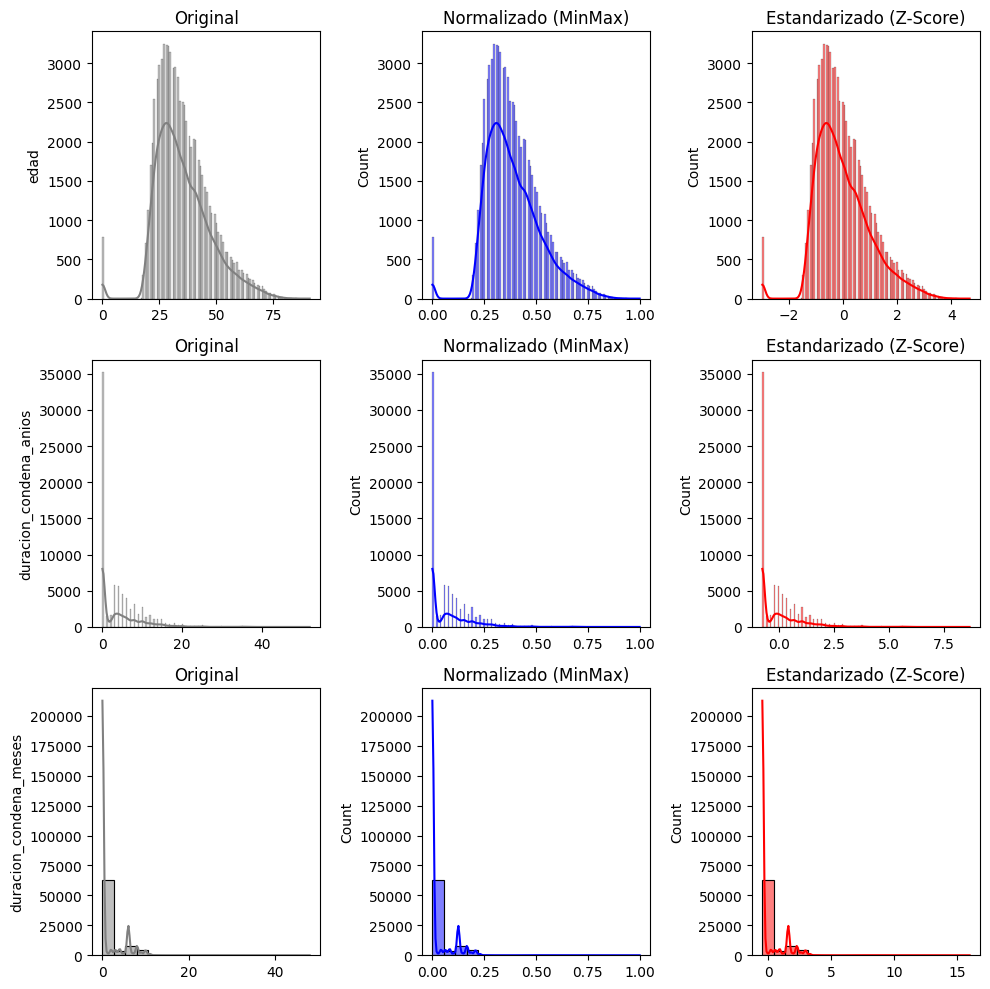

In [702]:
graficar_comparacion_transformaciones(df_original=X_train,
                                      df_normalizado=df_train_escalado,
                                      df_estandarizado=df_train_estandarizado,
                                      columns=col_numericas)

A continuación se grafica la distribución de las variables numéricas en los dataset de `test` *original*, *normalizado* y *estandarizado*.

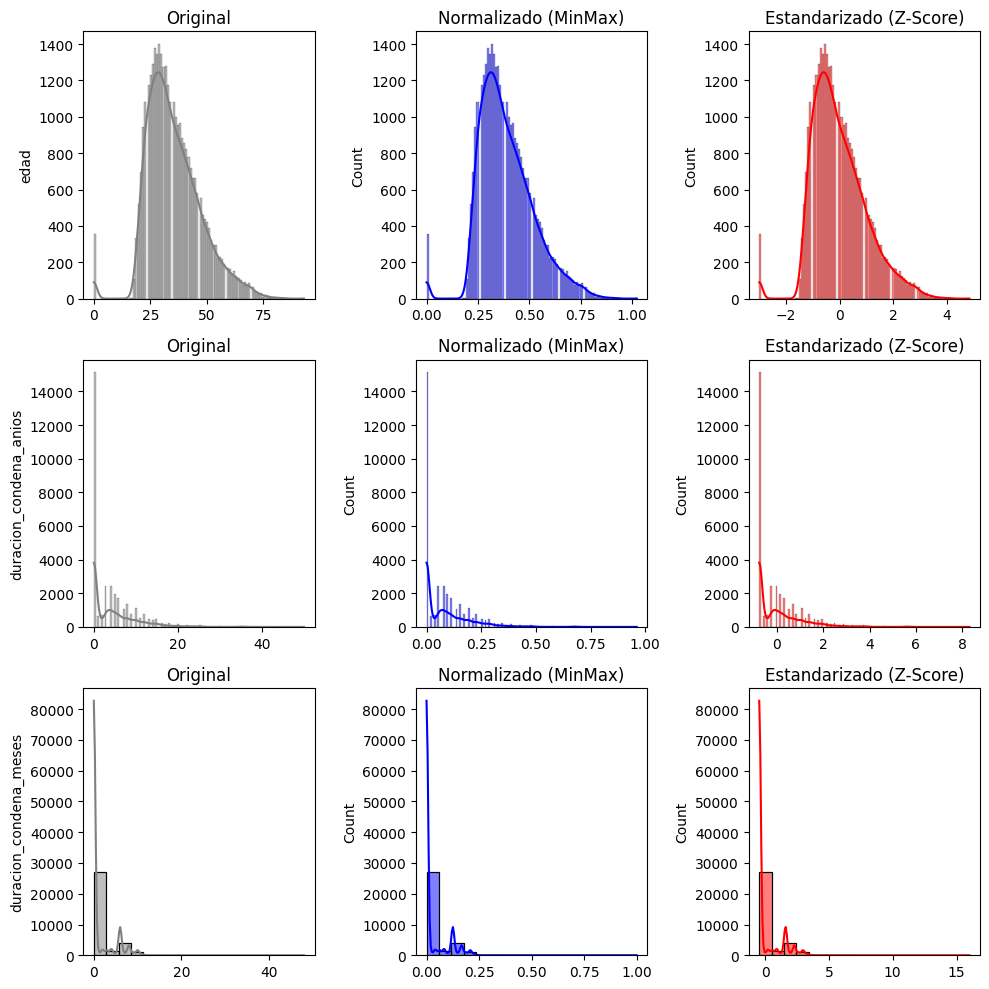

In [703]:
graficar_comparacion_transformaciones(df_original=X_test,
                                      df_normalizado=df_test_escalado,
                                      df_estandarizado=df_test_estandarizado,
                                      columns=col_numericas)

Como se puede observar en los gráficos, las distribuciones se mantienen para todas las variables, tanto al estandarizar como al normalizar los datasets de *train* y *test*.

Se opta por utilizar la estandarización de estas variables, ya que esta puede resultar útil al trabajar con algoritmos tales como `Regresión Lineal` y `SVM`, mientras que la normalización resulta útil para algoritmos tales como `KNN`, el cual es poco probable que se utilice en casos como este.

Por este motivo, reemplazaremos las columnas numéricas el los datasets *train* y *test* por sus valores `estandarizados`.

Antes de aplicar estos cambios a la variables `edad`, hay que recordar que esta variable presentaba un total de `785` datos nulos (con edad igual a cero).

Por eso, se valida que la cantidad de registros con valor mínimo de `edad` estandarizada (`-2.994274675689943`) sea también de `785`, lo cual se demuestra en las siguientes celdas:

In [704]:
df_train_estandarizado["edad"].min()

-2.9925445288900447

In [705]:
len(df_train_estandarizado[df_train_estandarizado["edad"] == df_train_estandarizado["edad"].min()])

787

In [706]:
len(X_train[X_train["edad"]==0])

787

### Paso 2.4 - Reemplazo de variables numéricas *originales* por estandarizadas

Se reemplazan las columnas numéricas originales en los datasets *train* y *test* por sus valores `estandarizados`.

In [ ]:
# El reset_index es necesario para actualizar correctamente los nuevos valores, sino genera nulos
X_train = X_train.reset_index()
X_test = X_test.reset_index()

for col in col_numericas:
    X_train[col] = df_train_estandarizado[col]
    X_test[col] = df_test_estandarizado[col]

## Paso 3 - Tratamiento de nulos

### Paso 3.1 - Repaso de nulos en el dataset

A continuación se repasan las variables que tienen datos faltantes y su tipo, según lo analizado en el `Trabajo Práctico nro. 1`.

| Columna | Cantidad de datos faltantes | Tipo de causa de datos faltantes | Comentarios |
| --- | --- | --- | --- |
| provincia_descripcion                               |       0 | - | - |
| establecimiento_descripcion                         |    3012 | MCAR | - |
| genero_descripcion                                  |       0 | - | - |
| nacionalidad_descripcion                            |     721 | MCAR | - |
| estado_civil_descripcion                            |    2891 | MCAR | - |
| nivel_instruccion_descripcion                       |    7737 | MCAR | - |
| ultima_situacion_laboral_descripcion                |     889 | MCAR | - |
| capacitacion_laboral_al_ingresar_descripcion        |    4205 | MCAR | - |
| ultimo_lugar_residencia_descripcion                 |      65 | MCAR | - |
| ultima_provincia_residencia_descripcion             |     591 | MCAR | - |
| jurisdiccion_descripcion                            |      12 | MCAR | - |
| situacion_legal_descripcion                         |       0 | - | - |
| establecimiento_procedencia_descripcion             |    1900 | MCAR | - |
| delito1_descripcion                                 |     590 | MCAR | - |
| delito2_descripcion                                 |   87909 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito3_descripcion                                 |  105385 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito4_descripcion                                 |  110104 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| delito5_descripcion                                 |  111446 | MAR | Valores nulos son correctos, ya que no necesariamente puede haber más de un delito (`delito1_descripcion`) |
| horas_trabajo_remunerado_descripcion                |     423 | MCAR | - |
| participacion_programa_educativo_descripcion        |    4179 | MCAR | - |
| participacion_actividades_deportivas                |    2227 | MCAR | - |
| recibio_atencion_medica_ult_anio_descripcion        |    4819 | MCAR | - |
| recibio_visitas_ultimo_anio                         |    2812 | MCAR | - |
| participo_alteracion_orden_ult_anio_descripcion     |    1838 | MCAR | - |
| tipo_infraccion_disciplinaria_descripcion           |    1589 | MCAR | - |
| sancion_aplicada_descripcion                        |   95702 | MCAR | - |
| calificacion_conducta_descripcion                   |    3737 | MCAR | - |
| tentativa_fugas_evasiones_descripcion               |     227 | MCAR | - |
| tentativa_suicidio                                  |       0 | - | - |
| fue_lesionado_descripcion                           |     665 | MCAR | - |
| tipo_condena                                        |   46325 | MAR | 96.31% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| es_reincidente_descripcion                          |   48931 | MAR | 91.18% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| tiene_periodo_progresividad_descripcion             |   47173 | MAR | 94.58% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| reparticion_descripcion                             |    3012 | MCAR | - |
| tuvo_salidas_transitorias_descripcion               |   48567 | MAR | 91.86% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| incorporado_reg_semi_libertad_descripcion           |   46364 | MAR | 96.23% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_pre_libertad                     |   47713 | MAR | 93.5% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_prision_discontinua_descripcion  |   48167 | MAR | 92.63% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| participa_programa_semi_detencion_descripcion       |   47465 | MAR | 94% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| tuvo_reduccion_pena_descripcion                     |   48275 | MAR | 92.41% de faltantes se deben a valores distintos de `Condenado/a` de la variable `situacion_legal_descripcion` |
| mujer_tiene_hijos_intramuro                         |  107325 | MAR | 100% de faltantes se deben a valores distintos de `Mujer` de la variable `genero_descripcion` |
| edad                                                |  1145   | MCAR  | Edad con valor igual a *cero*. |

### Paso 3.2 - Imputación de `MAR`

De la tabla del `Paso 3.1` se destacan los siguientes casos correspondientes a `MAR`:

1. Los valores distintos a `Condenado/a` en la variable `situacion_legal_descripcion` generan la mayoría de los valores *nulos* en las siguientes variables:
    1. `tipo_condena`, `es_reincidente_descripcion`, `tiene_periodo_progresividad_descripcion`, `tuvo_salidas_transitorias_descripcion`, `incorporado_reg_semi_libertad_descripcion`, `participa_programa_pre_libertad`, `participa_programa_prision_discontinua_descripcion`, `participa_programa_semi_detencion_descripcion` y `tuvo_reduccion_pena_descripcion`
    1. Esto es razonable, ya que estas variables describen situaciones correspondientes a personas que tienen condena.
1. Los valores *nulos* en la variable `mujer_tiene_hijos_intramuros` se deben a que el género (`genero_descripcion`) es distinto de `Mujer`, lo cual es lógico.
1. Las variables `delito2_descripcion`, `delito3_descripcion`, `delito4_descripcion` y `delito5_descripcion` tienen la mayoría de sus valores nulos. Esto se debe a que el registro NO necesariamente puede tener más de un delito.

Para resolverlos, se realizará lo siguiente:

1. Variables afectadas por `situacion_legal_descripcion`.
    1. Si `situacion_legal_descripcion` es ***distinto*** a `Condenado/a`, se imputará a cada una de las variables afectadas con el valor `Sin condena`.
    1. Si `situacion_legal_descripcion` es ***igual*** a `Condenado/a`, se imputará a cada una de las variables afectadas con la `moda` de este subjconjunto.
1. Registros con valores nulos en `mujer_tiene_hijos_intramuros`
    1. Si `genero_descripcion` es ***distinto*** a `Mujer`, se imputará con el valor `No aplica`
    1. Si `genero_descripcion` es ***igual*** a `Mujer`, se imputará con la `moda` de este subconjunto.
1. Las variables `delito2_descripcion`, `delito3_descripcion`, `delito4_descripcion` y `delito5_descripcion` serán eliminadas, ya que la mayoría son valores nulos.
    1. Los porcentajes de nulos son $78.51%$, $94.12%$, $98.34%$ y $99.53%$ respectivamente.

#### Paso 3.2.1 - Imputación de variables afectadas por valores distintos a `Condenado/a` en `situacion_legal_descripcion`

Primero, tenemos que convertir las variables `tipo_condena` y `participa_programa_pre_libertad` en string, ya que son (a priori) *booleanas*, pero sus valores son *float64*.

In [809]:
cols_to_string = [
    "tipo_condena",
    "participa_programa_pre_libertad"
]

for col in cols_to_string:
    train_not_na_mask = X_train[col].notna()
    test_not_na_mask = X_test[col].notna()

    X_train.loc[train_not_na_mask, col] = X_train.loc[train_not_na_mask, col].astype(str)
    X_test.loc[test_not_na_mask, col] = X_test.loc[test_not_na_mask, col].astype(str)

C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1140\864544693.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '1.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_train.loc[train_not_na_mask, col] = X_train.loc[train_not_na_mask, col].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1140\864544693.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['0.0' '0.0' '0.0' ... '0.0' '0.0' '0.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_test.loc[test_not_na_mask, col] = X_test.loc[test_not_na_mask, col].astype(str)
C:\Users\GasparAcevedo\AppData\Local\Temp\ipykernel_1140\864544693.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pan

In [810]:
const_condenado = "Condenado/a"
const_sin_condena = "Sin condena"
cols_afectadas_condenado = [
    "tipo_condena",
    "es_reincidente_descripcion",
    "tiene_periodo_progresividad_descripcion",
    "tuvo_salidas_transitorias_descripcion",
    "incorporado_reg_semi_libertad_descripcion",
    "participa_programa_pre_libertad",
    "participa_programa_prision_discontinua_descripcion",
    "participa_programa_semi_detencion_descripcion"
    #"tuvo_reduccion_pena_descripcion"
]

mask_condenados_train = X_train["situacion_legal_descripcion"] == const_condenado
mask_NO_condenados_train = X_train["situacion_legal_descripcion"] != const_condenado

mask_condenados_test = X_test["situacion_legal_descripcion"] == const_condenado
mask_NO_condenados_test = X_test["situacion_legal_descripcion"] != const_condenado

Imputamos los registros con `situacion_legal_descripcion` distinto a `Condenado/a` con el valor `Sin condena`

In [811]:
# Imputamos las columnas con valores DISTINTOS a Condenado/a, utilizando el valor `Sin condena`.

for col in cols_afectadas_condenado:
    X_train.loc[mask_NO_condenados_train, col] = const_sin_condena
    X_test.loc[mask_NO_condenados_test, col] = const_sin_condena

In [812]:
# Variable "tuvo_reduccion_pena_descripcion" es el target, por lo tanto actualizamos y_train e y_test.
y_train[mask_NO_condenados_train] = const_sin_condena
y_test[mask_NO_condenados_test] = const_sin_condena

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

Imputamos los registros con `situacion_legal_descripcion` igual a `Condenado/a` con la moda

In [ ]:
for col in cols_afectadas_condenado:
    moda = X_train[mask_condenados_train][col].mode()[0]

    print(f"La columna {col} se imputará con la moda \"{moda}\"")
    X_train.loc[mask_condenados_train & (X_train[col]).isna(), col] = moda
    X_test.loc[mask_condenados_train & (X_test[col]).isna(), col] = moda

La columna tipo_condena se imputará con la moda "0.0"
La columna es_reincidente_descripcion se imputará con la moda "Primario/a"
La columna tiene_periodo_progresividad_descripcion se imputará con la moda "Período de tratamiento"
La columna tuvo_salidas_transitorias_descripcion se imputará con la moda "No le fueron otorgadas"
La columna incorporado_reg_semi_libertad_descripcion se imputará con la moda "No está incorporado/a al régimen de semilibertad"
La columna participa_programa_pre_libertad se imputará con la moda "0.0"
La columna participa_programa_prision_discontinua_descripcion se imputará con la moda "No está incorporado/a"
La columna participa_programa_semi_detencion_descripcion se imputará con la moda "No tiene semidetención"


Imputamos nulos en la variable target

Recordemos que al hacer el split seteamos los nulos con el string `nan`. Por eso, primero revertimos ese paso:

In [ ]:
# reemplaza los valores distintos al string 'nan' con np.nan
y_train = y_train.where(y_train != 'nan', other=np.nan)
y_test = y_test.where(y_test != 'nan', other=np.nan)

In [ ]:
moda_target = y_train[mask_condenados_train].mode()[0]

y_train[mask_condenados_train] = y_train[mask_condenados_train].fillna(moda_target)
y_test[mask_condenados_test] = y_test[mask_condenados_test].fillna(moda_target)

#### Paso 3.2.2 - Imputación con moda de variable `mujer_tiene_hijos_intramuro`

In [ ]:
const_mujer = "Mujer"
const_no_aplica = "No aplica"

mask_mujer_train = X_train["genero_descripcion"] == const_mujer
mask_NO_mujer_train = X_train["genero_descripcion"] != const_mujer

mask_mujer_test = X_test["genero_descripcion"] == const_mujer
mask_NO_mujer_test = X_test["genero_descripcion"] != const_mujer

In [ ]:
# Convertimos la variable "mujer_tiene_hijos_intramuro" en string
train_not_na_mask = X_train["mujer_tiene_hijos_intramuro"].notna()
test_not_na_mask = X_test["mujer_tiene_hijos_intramuro"].notna()

X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_train.loc[train_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)
X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"] = X_test.loc[test_not_na_mask, "mujer_tiene_hijos_intramuro"].astype(str)

Imputamos los casos que no son `Mujer` con el valor `No aplica` para la columna `mujer_tiene_hijos_intramuro`

In [ ]:
# Imputamos los nulos para los casos que NO corresponden a `Mujer`
X_train.loc[mask_NO_mujer_train, "mujer_tiene_hijos_intramuro"] = const_no_aplica
X_test.loc[mask_NO_mujer_test, "mujer_tiene_hijos_intramuro"] = const_no_aplica

En cuanto a los registros que si son `Mujer`, observamos que la columna `mujer_tiene_hijos_intramuro` no presenta nulos.

In [ ]:
X_train[mask_mujer_train]["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
0.0    3212
1.0      43
Name: count, dtype: int64

In [ ]:
X_test[mask_mujer_test]["mujer_tiene_hijos_intramuro"].value_counts()

mujer_tiene_hijos_intramuro
0.0    1360
1.0      27
Name: count, dtype: int64

#### Paso 3.2.3 - Cálculo de porcentajes de nulos en variables `delito` y eliminación

In [ ]:
# Se muestran la cantidad de nulos para las columnas de delitos
delitos = ["delito2_descripcion", "delito3_descripcion", "delito4_descripcion", "delito5_descripcion"]

total_registros = len(df_procesado)

for delito in delitos:
    cant_na = len(df_procesado[df_procesado[delito].isna()])
    print(f"Porcentaje de nulos en columna {delito}: {np.round(cant_na*100/total_registros, 2)}%")

In [ ]:
X_train = X_train.drop(columns=delitos)
X_test = X_test.drop(columns=delitos)

### Paso 3.3 - Imputación de `MCAR`

Las siguientes variables son las que presentan nulos del tipo `MCAR`:

| Columna | Cantidad de datos faltantes | Comentarios |
| --- | --- | --- |
| establecimiento_descripcion                         |    3012 | - |
| nacionalidad_descripcion                            |     721 | - |
| estado_civil_descripcion                            |    2891 | - |
| nivel_instruccion_descripcion                       |    7737 | - |
| ultima_situacion_laboral_descripcion                |     889 | - |
| capacitacion_laboral_al_ingresar_descripcion        |    4205 | - |
| ultimo_lugar_residencia_descripcion                 |      65 | - |
| ultima_provincia_residencia_descripcion             |     591 | - |
| jurisdiccion_descripcion                            |      12 | - |
| establecimiento_procedencia_descripcion             |    1900 | - |
| delito1_descripcion                                 |     590 | - |
| horas_trabajo_remunerado_descripcion                |     423 | - |
| participacion_programa_educativo_descripcion        |    4179 | - |
| participacion_actividades_deportivas                |    2227 | - |
| recibio_atencion_medica_ult_anio_descripcion        |    4819 | - |
| recibio_visitas_ultimo_anio                         |    2812 | - |
| participo_alteracion_orden_ult_anio_descripcion     |    1838 | - |
| tipo_infraccion_disciplinaria_descripcion           |    1589 | - |
| sancion_aplicada_descripcion                        |   95702 | - |
| calificacion_conducta_descripcion                   |    3737 | - |
| tentativa_fugas_evasiones_descripcion               |     227 | - |
| fue_lesionado_descripcion                           |     665 | - |
| reparticion_descripcion                             |    3012 | - |
| edad                                                |  1145   | Edad con valor igual a *cero*. |

Como se observa en la tabla anterior, tenemos dos casos particulares:

1. La variable `sancion_aplicada_descripcion` presenta nulos en el $85.47%$ de los registros.
1. La variable `edad` tiene $1145$ (aproximadamente el $1%$) de valores con edad igual a cero.

Estos se resolverán de la siguiente manera:

1. La variable `sancion_aplicada_descripcion` será eliminada, ya que la mayoría de los registros tiene valores nulos.
1. Para la variable `edad` se imputarán los datos, en función de lo siguiente:
    1. Imputación por media: si los datos presentan distribución (aproximadamente) Normal (en el dataset de *train*).
    1. Imputación por mediana: si los datos NO presentan distribución (aproximadamente) Normal (en el dataset de *train*).

El resto de las variables serán imputadas por la *moda* (del dataset *train*), ya que son categóricas.

### Paso 3.3.1 - Imputación de la variable `edad` con `mediana`

Debido a que la variable edad fue *estandarizada* en el `paso 2.4`, los valores correspondientes a cero ahora son iguales a $-2.9925445288900447$.

*X_train* tiene $787$ registros nulos (o registros con valor mínimo) y *X_test* tiene *358* registros nulos.

In [813]:
const_edad = "edad"

edad_min_xtrain = X_train[const_edad].min()
edad_min_xtest = X_test[const_edad].min()

print(f"Edad mínimo post estandarizado: {edad_min_xtrain}")
print(f"Train y test tienen el mismo mínimo? {edad_min_xtrain == edad_min_xtest}")

Edad mínimo post estandarizado: -2.9925445288900447
Train y test tienen el mismo mínimo? True


In [814]:
mask_min_edad_train = X_train[const_edad] == edad_min_xtrain
mask_min_edad_test = X_test[const_edad] == edad_min_xtrain

In [815]:
print(f"Cantidad de mínimo en X_train para edad: {len(X_train[mask_min_edad_train])}")
print(f"Cantidad de mínimo en X_test para edad: {len(X_test[mask_min_edad_test])}")

Cantidad de mínimo en X_train para edad: 787
Cantidad de mínimo en X_test para edad: 358


Se grafica la distribución de `edad` para determinar con qué métrica se imputará.

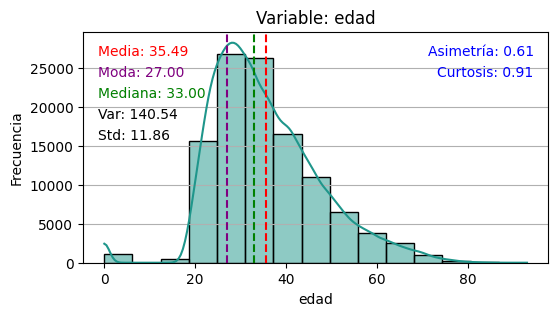

In [ ]:
plot_histograma(data=df_procesado, column=const_edad, snk=True, xlabel=const_edad)

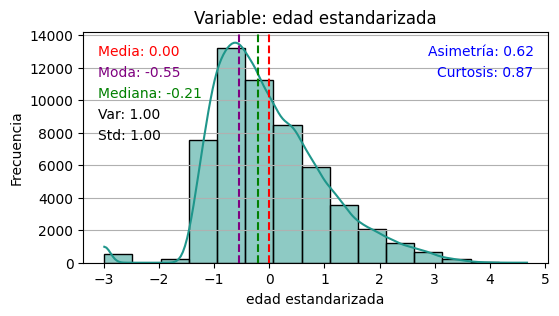

In [672]:
plot_histograma(data=X_train, column=const_edad, snk=True, xlabel="edad estandarizada")

Como se observa en los gráficos anteriores, tanto la variable original como la estandarizada presentan `asimetría` (con un valor de $0.62$).

Debido a esto, se decide imputar los valores correspondientes a cero en la `edad estandarizada` utilizando la `mediana`.

In [817]:
mediana_edad_estandarizada = (X_train[const_edad]).median()

In [826]:
X_train[const_edad] = (X_train[const_edad]).replace(edad_min_xtrain, mediana_edad_estandarizada)

In [827]:
X_test[const_edad] = (X_test[const_edad]).replace(edad_min_xtest, mediana_edad_estandarizada)